# UHJ Lightcurve Visual Inspection
Loads all Ultra-Hot Jupiter planets across all batches, downloads TESS SPOC 2-min lightcurves, and plots each planet's sectors in a grid for visual confirmation of transit dips.

In [1]:
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightkurve as lk
from IPython.display import display

warnings.filterwarnings('ignore')

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
FOLDER   = os.path.join(BASE_DIR, 'Final HJ and UHJ')
NCOLS    = 5

# Load all UHJ CSVs and combine
uhj_files = [f for f in os.listdir(FOLDER) if f.startswith('ultra_hot') and f.endswith('.csv')]
frames = []
for f in sorted(uhj_files):
    df = pd.read_csv(os.path.join(FOLDER, f))
    df['source'] = f
    frames.append(df)

uhj_all = pd.concat(frames, ignore_index=True).drop_duplicates('Planet')
uhj_all = uhj_all.sort_values('Transit_depth_pct', ascending=False).reset_index(drop=True)

print(f'{len(uhj_all)} unique UHJ planets found across {len(uhj_files)} files:')
display(uhj_all[['Planet','Period_days','Radius_Rjup','Transit_depth_pct','StarRadius_Rsun','SemiMajorAxis_AU','source']])

19 unique UHJ planets found across 4 files:


c:\Users\pnayg\Desktop\cvif-astro-p1\.venv\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


,Planet,Period_days,Radius_Rjup,Transit_depth_pct,StarRadius_Rsun,SemiMajorAxis_AU,source
0,WASP-121,1.275,1.7420,1.501346,1.461,0.02571,ultra_hot_jupiters_top5.csv
1,WASP-103,0.926,1.6460,1.433047,1.413,0.01979,ultra_hot_jupiters_top5.csv
2,WASP-012,1.091,1.9650,1.427699,1.690,0.02340,ultra_hot_jupiters_top5.csv
3,WASP-033,1.220,1.6650,1.285686,1.509,0.02555,ultra_hot_jupiters_top5.csv
4,KELT-16,0.969,1.3830,1.168094,1.315,0.02035,ultra_hot_jupiters_top5.csv
5,OGLE-TR-056,1.212,1.7340,1.052407,1.737,0.02453,ultra_hot_jupiters_batch2.csv
6,WASP-076,1.810,1.7730,1.001112,1.821,0.03300,ultra_hot_jupiters_batch2.csv
7,TOI-1518,1.903,1.8750,0.976379,1.950,0.03890,ultra_hot_jupiters_batch2.csv
8,WASP-018,0.941,1.1926,0.952128,1.256,0.02041,ultra_hot_jupiters_batch2.csv
9,GPX-1,1.745,1.4700,0.937714,1.560,0.03380,ultra_hot_jupiters_batch2.csv


In [2]:
R_sun = 6.957e8
R_jup = 7.149e7
AU    = 1.496e11

def estimate_T14(P_days, R_star_rsun, R_p_rjup, a_AU):
    R_s = R_star_rsun * R_sun
    R_p = R_p_rjup   * R_jup
    a   = a_AU * AU
    return (P_days / np.pi) * np.arcsin(np.clip((R_s + R_p) / a, 0, 1))

def clean_lc(lc, sigma=3.0):
    lc   = lc.remove_nans().remove_outliers(sigma=sigma)
    time = np.asarray(lc.time.value, dtype=float)
    flux = np.asarray(lc.flux.value, dtype=float)
    flux = flux / np.nanmedian(flux)
    return time, flux

# Build planet params
PLANET_PARAMS = {}
for _, row in uhj_all.iterrows():
    planet = row['Planet']
    P      = row['Period_days']
    T14_d  = estimate_T14(P, row['StarRadius_Rsun'], row['Radius_Rjup'], row['SemiMajorAxis_AU'])
    PLANET_PARAMS[planet] = dict(P=P, T14_d=T14_d, T14_h=T14_d*24,
                                 R_b=row['Radius_Rjup'], depth=row['Transit_depth_pct'])

param_summary = pd.DataFrame([
    {'Planet': k, 'Period_days': v['P'], 'T14_h': round(v['T14_h'], 2),
     'depth_%': v['depth'], 'R_b_Rjup': v['R_b']}
    for k, v in PLANET_PARAMS.items()
])
print('Estimated T14 for all UHJ planets:')
display(param_summary)

Estimated T14 for all UHJ planets:


,Planet,Period_days,T14_h,depth_%,R_b_Rjup
0,WASP-121,1.275,2.93,1.501346,1.7420
1,WASP-103,0.926,2.69,1.433047,1.6460
2,WASP-012,1.091,3.21,1.427699,1.9650
3,WASP-033,1.220,2.90,1.285686,1.6650
4,KELT-16,0.969,2.51,1.168094,1.3830
5,OGLE-TR-056,1.212,3.44,1.052407,1.7340
6,WASP-076,1.810,3.96,1.001112,1.7730
7,TOI-1518,1.903,3.77,0.976379,1.8750
8,WASP-018,0.941,2.30,0.952128,1.1926
9,GPX-1,1.745,3.17,0.937714,1.4700


## Lightcurve Grid — All UHJ Planets
One figure per planet, one subplot per sector. No overlays — raw flux only so dips are directly visible.

[WASP-121] Downloading...
  6 sector(s) — plotting...


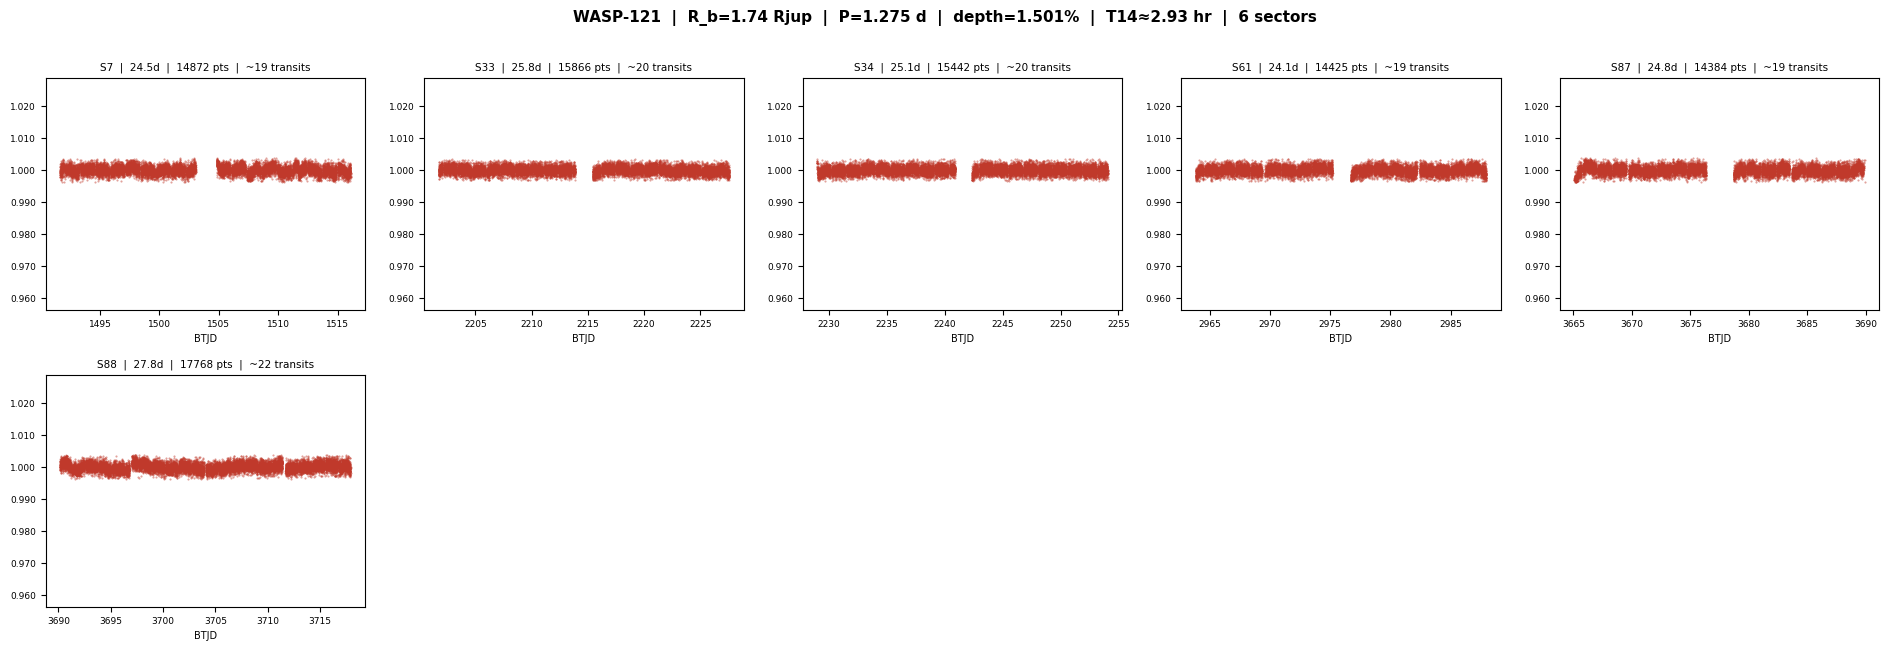

  Done.

[WASP-103] Downloading...


No data found for target "WASP-103".


  No SPOC 2-min data found — skipped.

[WASP-012] Downloading...
  6 sector(s) — plotting...


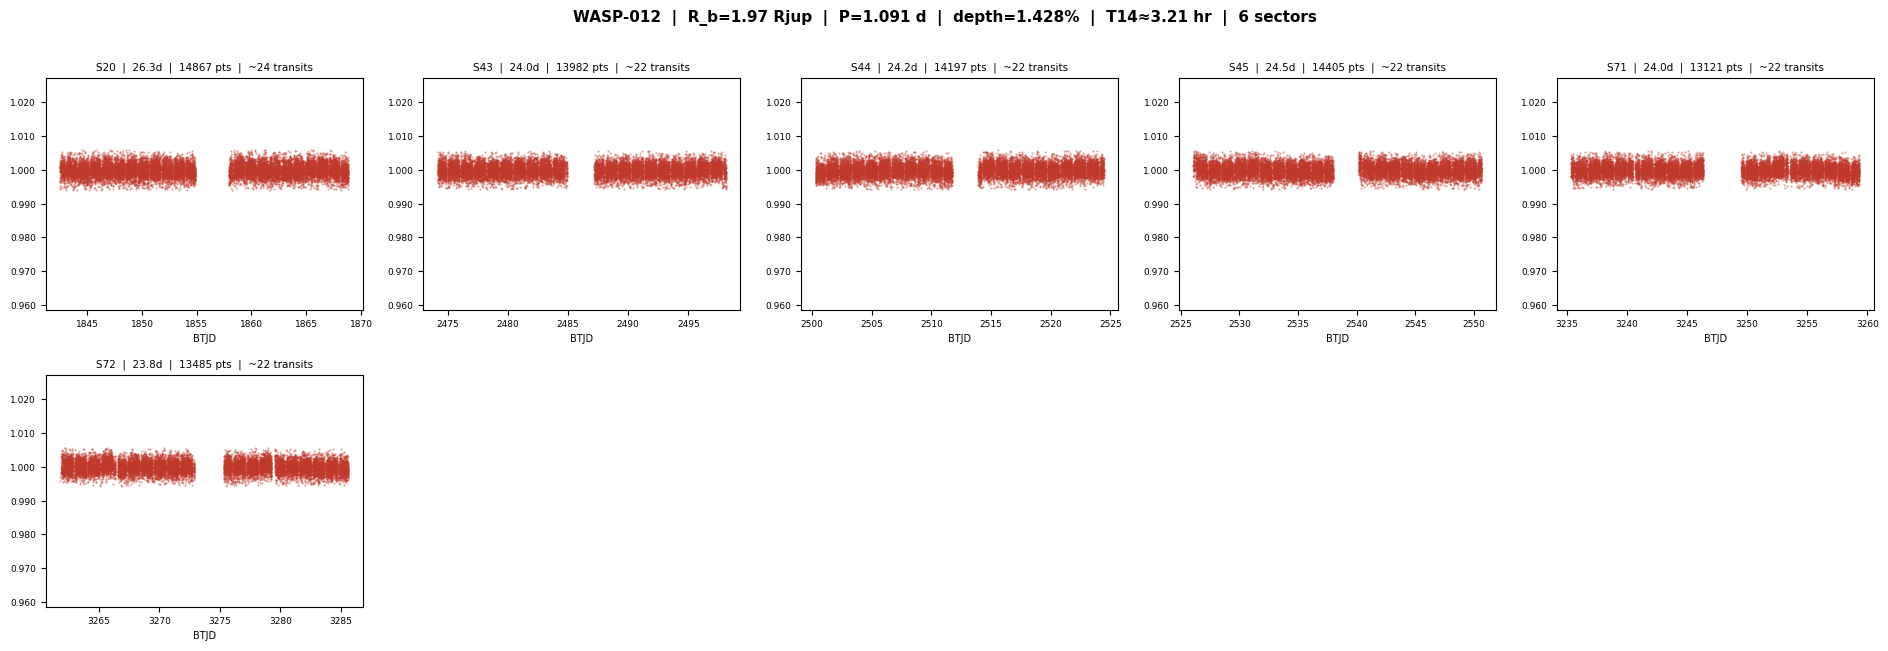

  Done.

[WASP-033] Downloading...
  Download error: HTTPSConnectionPool(host='mastresolver.stsci.edu', port=443): Read timed out. (read timeout=None)

[KELT-16] Downloading...
  Download error: HTTPConnectionPool(host='mastresolver.stsci.edu', port=80): Read timed out. (read timeout=None)

[OGLE-TR-056] Downloading...
  4 sector(s) — plotting...


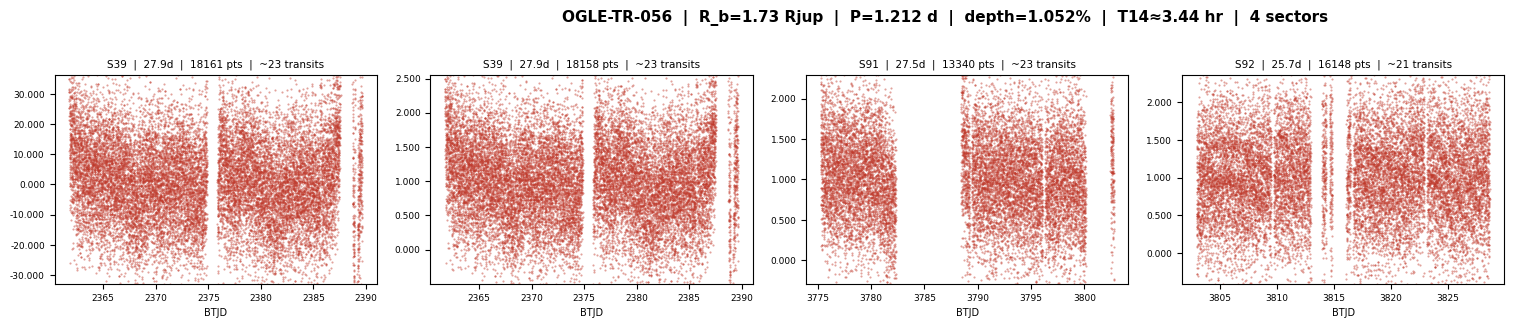

  Done.

[WASP-076] Downloading...
  4 sector(s) — plotting...


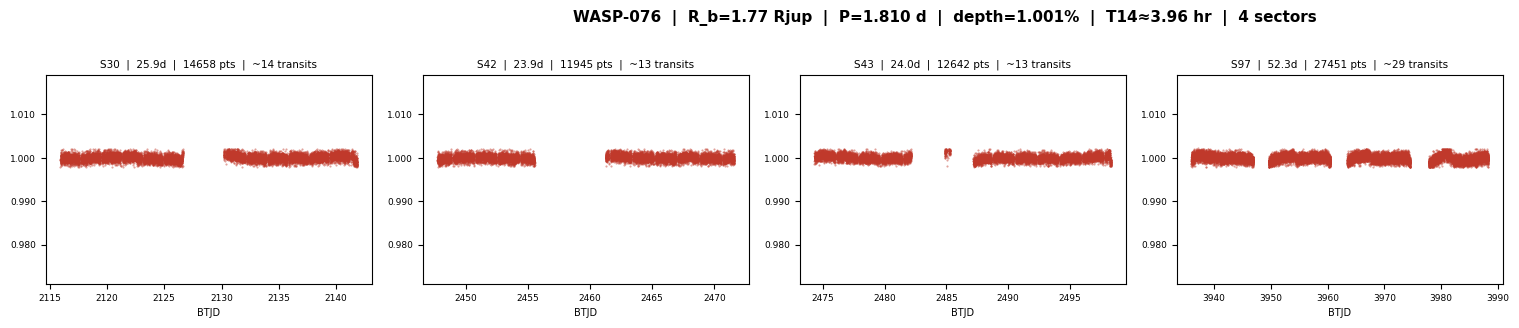

  Done.

[TOI-1518] Downloading...
  5 sector(s) — plotting...


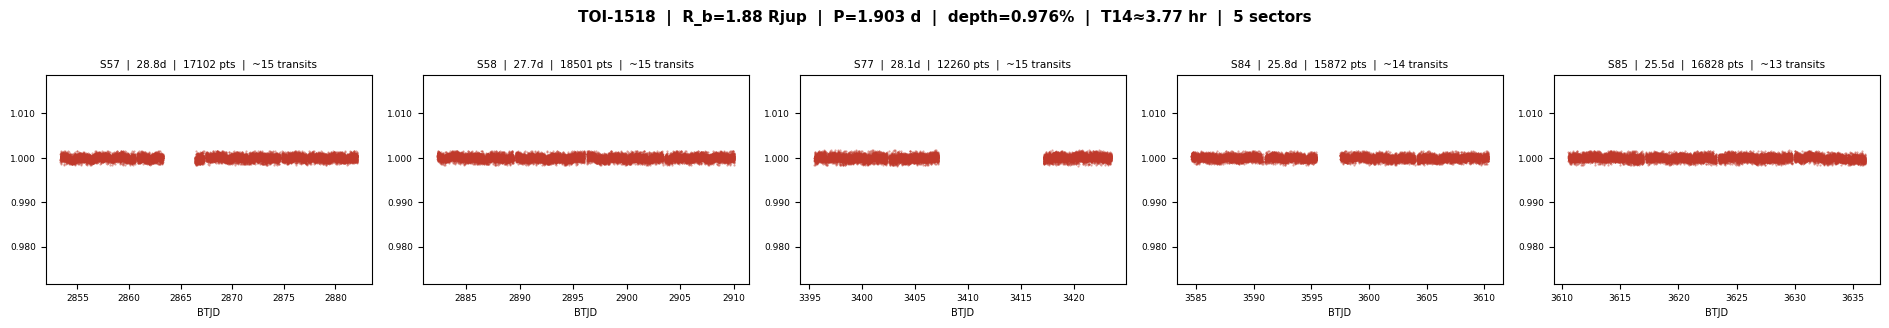

  Done.

[WASP-018] Downloading...


  6 sector(s) — plotting...


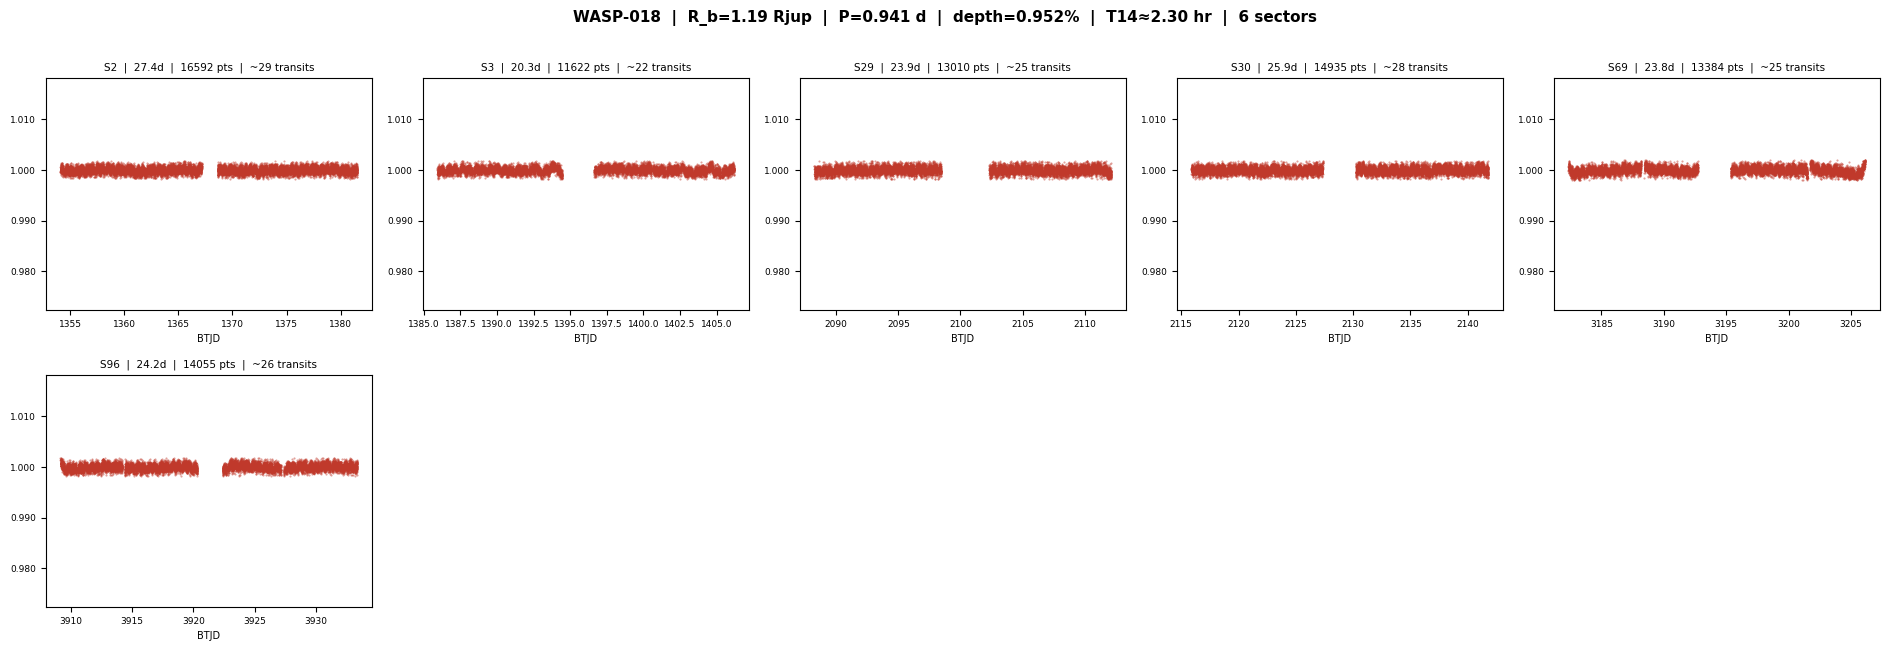

  Done.

[GPX-1] Downloading...
  2 sector(s) — plotting...


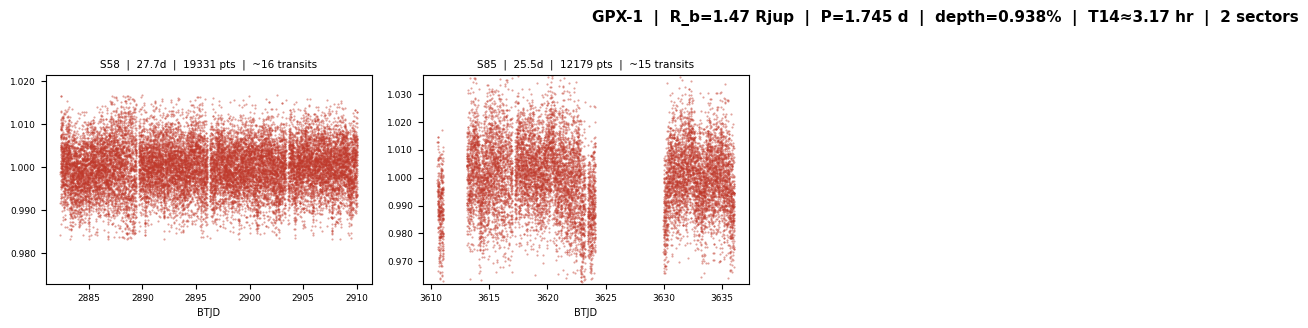

  Done.

[WASP-078] Downloading...
  3 sector(s) — plotting...


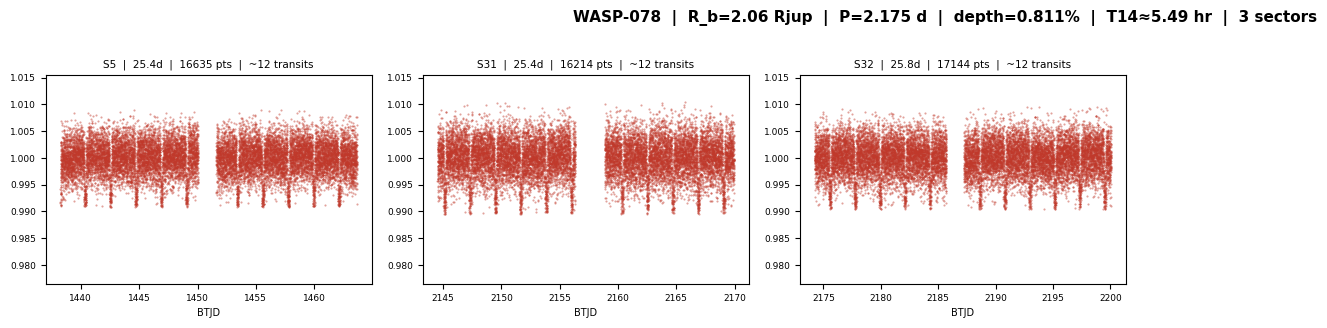

  Done.

[TOI-4773] Downloading...
  2 sector(s) — plotting...


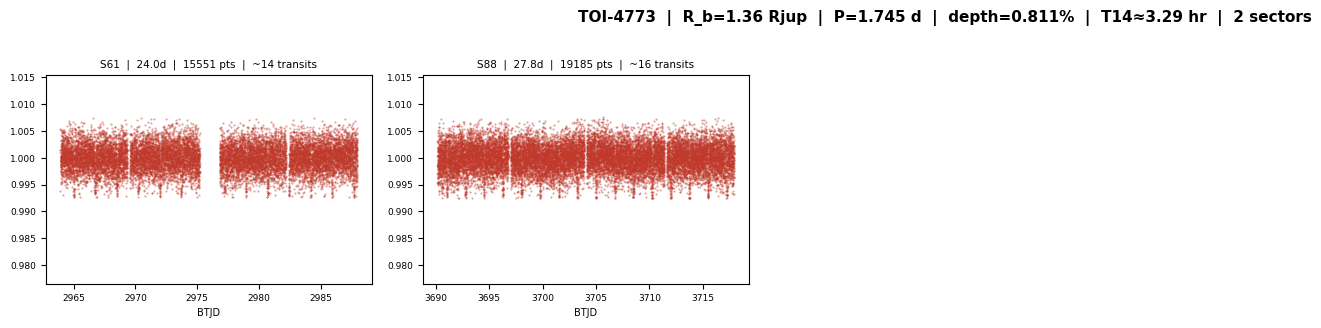

  Done.

[WASP-167] Downloading...
  5 sector(s) — plotting...


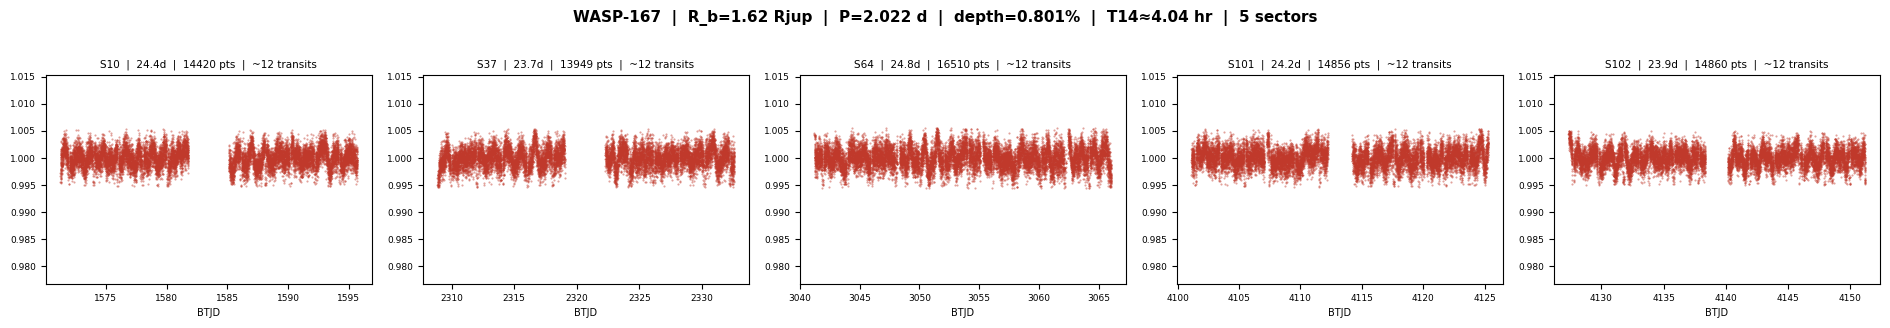

  Done.

[WASP-087] Downloading...
  Download error: Download of mast:TESS/product/tess2021091135823-s0037-0000000015445551-0208-s_lc.fits failed. MAST returns ERROR: HTTPError: 404 Client Error: Not Found for url: https://stpubdata.s3.us-east-1.amazonaws.com/tess/public/tid/s0037/0000/0000/1544/5551/tess2021091135823-s0037-0000000015445551-0208-s_lc.fits

[TOI-2109] Downloading...


  2 sector(s) — plotting...


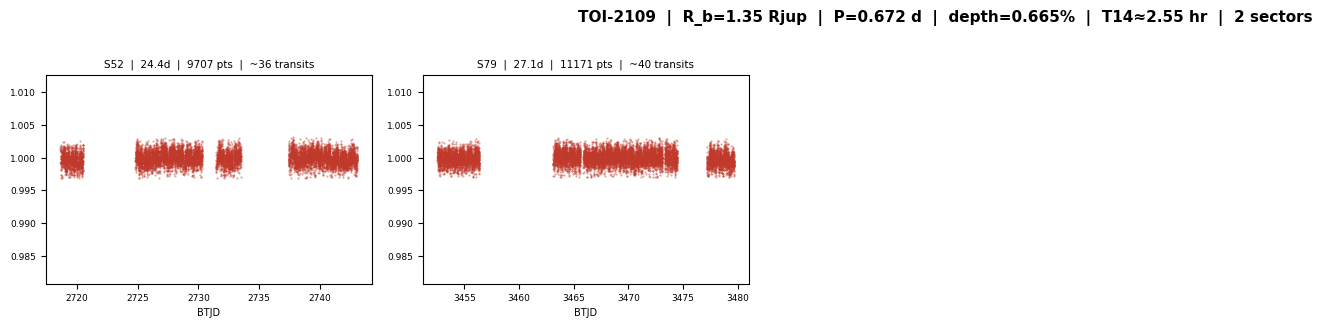

  Done.

[WASP-082] Downloading...
  2 sector(s) — plotting...


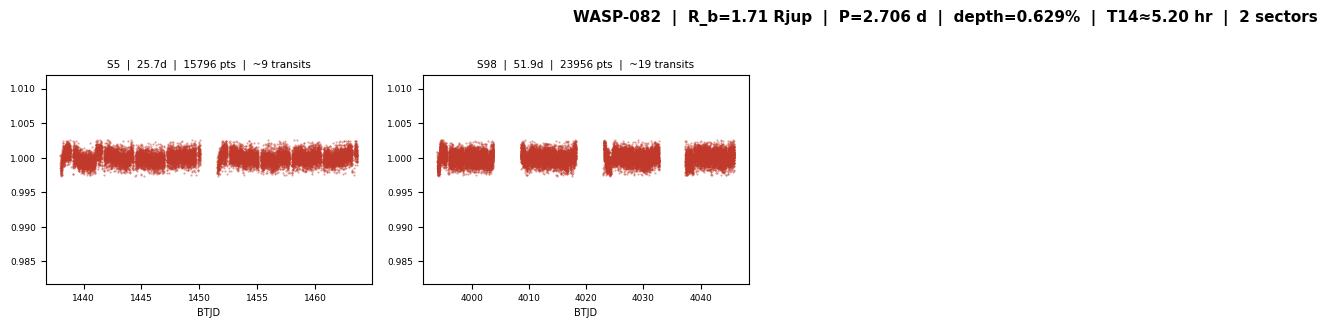

  Done.

[KELT-01] Downloading...
  3 sector(s) — plotting...


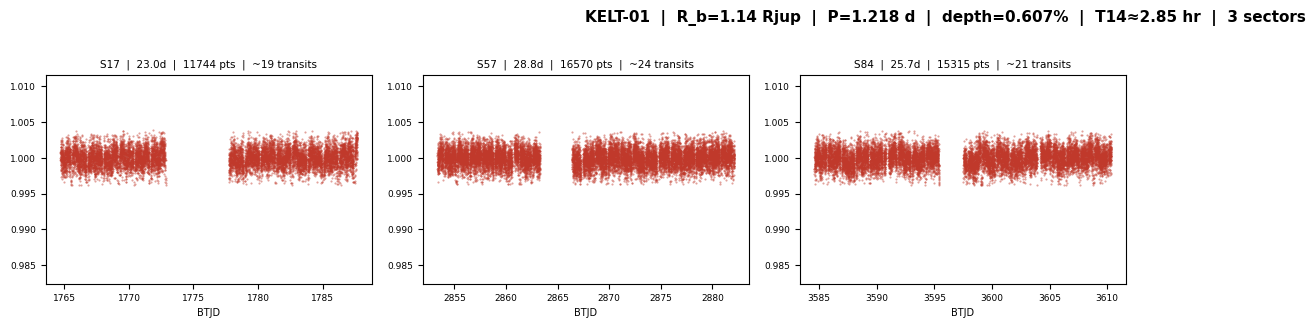

  Done.

[HAT-P-07] Downloading...
  10 sector(s) — plotting...


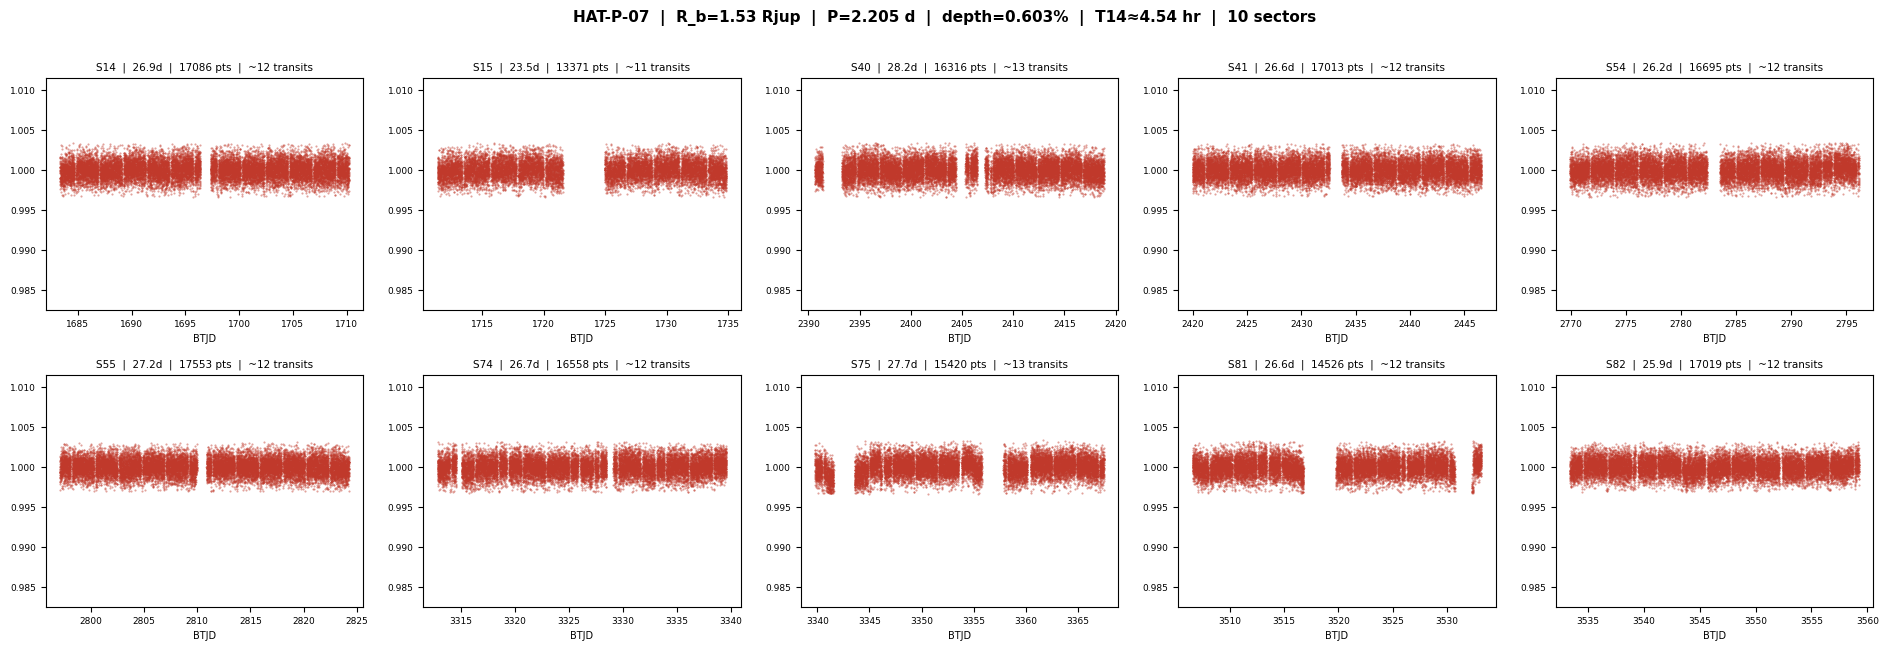

  Done.

[WASP-072] Downloading...


  5 sector(s) — plotting...


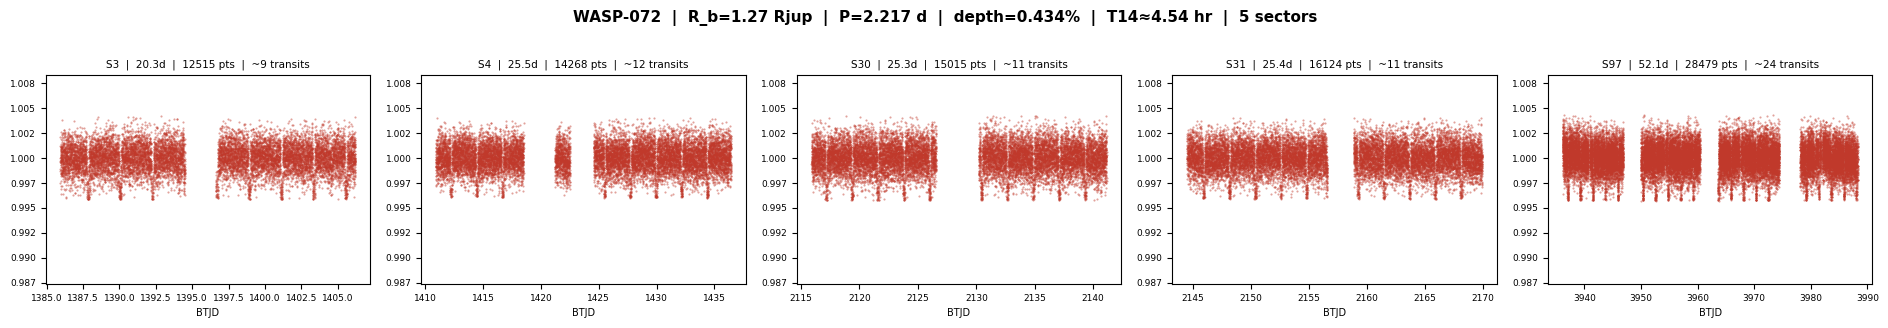

  Done.



In [3]:
for planet, p in PLANET_PARAMS.items():
    P      = p['P']
    T14_d  = p['T14_d']
    T14_h  = p['T14_h']
    R_b    = p['R_b']
    depth  = p['depth']

    print(f'[{planet}] Downloading...', flush=True)
    try:
        sr = lk.search_lightcurve(planet, mission='TESS', cadence=120, author='SPOC')
        if len(sr) == 0:
            print(f'  No SPOC 2-min data found — skipped.\n')
            continue
        lc_collection = sr.download_all(quality_bitmask='default')
    except Exception as e:
        print(f'  Download error: {e}\n')
        continue

    n_sectors = len(lc_collection)
    nrows     = math.ceil(n_sectors / NCOLS)
    print(f'  {n_sectors} sector(s) — plotting...', flush=True)

    fig, axes = plt.subplots(nrows, NCOLS,
                             figsize=(NCOLS * 3.8, nrows * 3.2),
                             squeeze=False)
    fig.suptitle(
        f'{planet}  |  R_b={R_b:.2f} Rjup  |  P={P:.3f} d  |  '
        f'depth={depth:.3f}%  |  T14≈{T14_h:.2f} hr  |  {n_sectors} sectors',
        fontsize=11, fontweight='bold', y=1.01
    )

    depth_frac = depth / 100.0

    for idx, lc_raw in enumerate(lc_collection):
        row_i      = idx // NCOLS
        col_i      = idx  % NCOLS
        ax         = axes[row_i][col_i]
        sector_num = lc_raw.meta.get('SECTOR', '?')

        try:
            time, flux = clean_lc(lc_raw)
        except Exception as e:
            ax.set_title(f'S{sector_num} — error', fontsize=8)
            ax.axis('off')
            continue

        span_d    = time[-1] - time[0]
        n_transit = round(span_d / P)

        ax.plot(time, flux, '.', ms=1.0, color='#c0392b', alpha=0.5, zorder=2)

        # Y-limits: always show at least 3× the transit depth below 1.0
        flux_p1  = np.nanpercentile(flux, 1)
        flux_p99 = np.nanpercentile(flux, 99)
        margin   = max(3 * depth_frac, (flux_p99 - flux_p1) * 0.1, 0.002)
        ylo = min(flux_p1,  1.0 - 2 * depth_frac) - margin * 0.3
        yhi = max(flux_p99, 1.0 + depth_frac)     + margin * 0.3
        ax.set_ylim(ylo, yhi)

        ax.set_title(
            f'S{sector_num}  |  {span_d:.1f}d  |  {len(time)} pts  |  ~{n_transit} transits',
            fontsize=7.5
        )
        ax.set_xlabel('BTJD', fontsize=7)
        ax.tick_params(labelsize=6.5)
        ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))

    for idx in range(n_sectors, nrows * NCOLS):
        axes[idx // NCOLS][idx % NCOLS].set_visible(False)

    plt.tight_layout()
    plt.show()
    print(f'  Done.\n', flush=True)

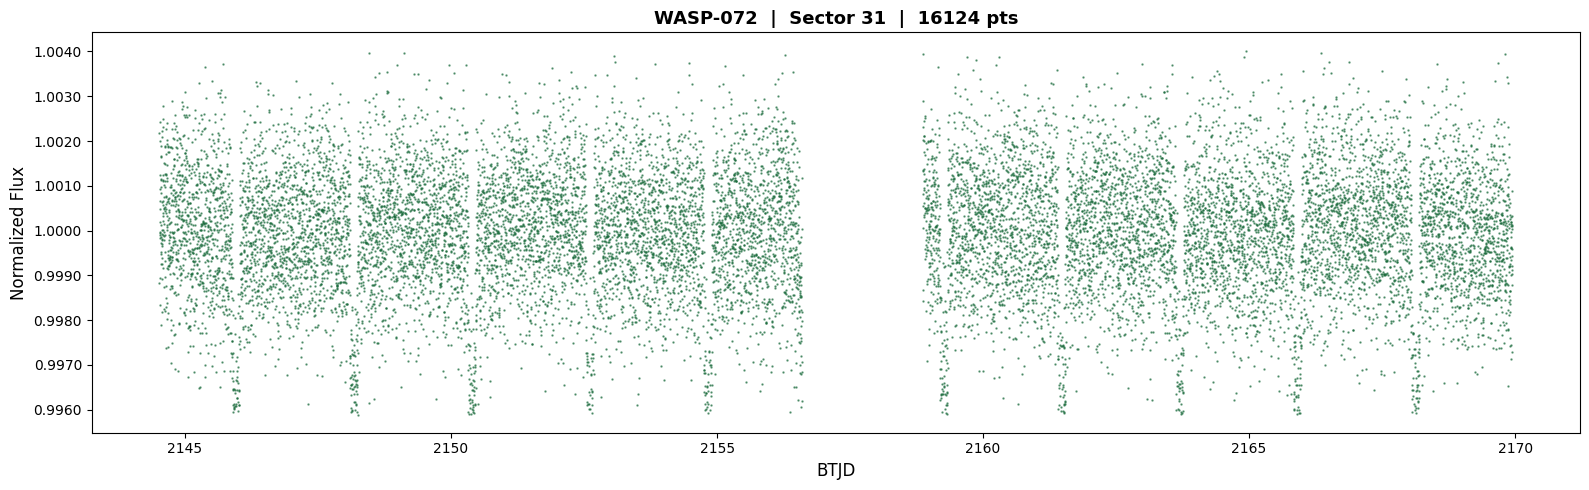

Time range: 2144.519 – 2169.948 BTJD  (25.4 d)


In [ ]:
# ── EDIT THESE ──────────────────────────────────────────────────────────────
PLANET   = 'NGTS-03'
SECTOR   = 31

# ────────────────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk

sr = lk.search_lightcurve(PLANET, mission='TESS', cadence=120, author='SPOC', sector=SECTOR)
if len(sr) == 0:
    print(f'No SPOC 2-min data for {PLANET} sector {SECTOR}.')
else:
    lc = sr.download(quality_bitmask='default')
    lc = lc.remove_nans().remove_outliers(sigma=3.0)
    time = np.asarray(lc.time.value, dtype=float)
    flux = np.asarray(lc.flux.value, dtype=float)
    flux = flux / np.nanmedian(flux)

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(time, flux, '.', ms=1.5, color='#1a6b3c', alpha=0.6)
    ax.set_xlabel('BTJD', fontsize=12)
    ax.set_ylabel('Normalized Flux', fontsize=12)
    ax.set_title(f'{PLANET}  |  Sector {SECTOR}  |  {len(time)} pts', fontsize=13, fontweight='bold')
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.4f'))
    ax.tick_params(labelsize=10)
    plt.tight_layout()
    plt.show()
    print(f'Time range: {time[0]:.3f} – {time[-1]:.3f} BTJD  ({time[-1]-time[0]:.1f} d)')